In [26]:
# ---- Manejo de datos ----
import numpy as np                     # arrays y operaciones numéricas
import pandas as pd                    # DataFrames para tabular
import matplotlib.pyplot as plt        # gráficos

# ---- Datasets ----
#   load_breast_cancer  → dataset de cáncer ya incluido en sklearn
#   make_classification → genera un dataset SINTÉTICO con las propiedades que queramos
#   fetch_openml        → descarga datasets desde el repositorio público OpenML.org
from sklearn.datasets import load_breast_cancer, make_classification, fetch_openml

# ---- Utilidad para dividir en train/test ----
from sklearn.model_selection import train_test_split

# ---- Modelos de clasificación que usaremos ----
from sklearn.linear_model import LogisticRegression       # regresión logística (modelo base)
from sklearn.ensemble import RandomForestClassifier       # bosque aleatorio (para comparar en el reto)
from sklearn.dummy import DummyClassifier                 # modelo "tonto" para baseline

# ---- Pre-procesado ----
from sklearn.preprocessing import StandardScaler          # estandariza features (media=0, std=1)

# ---- Las protagonistas: métricas ----
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,    # las 4 métricas básicas
    confusion_matrix, classification_report,                    # vista global de las métricas
    roc_curve, auc, precision_recall_curve, average_precision_score,  # curvas
    ConfusionMatrixDisplay                                      # plot de la matriz de confusión
)

# ---- Para mostrar imágenes externas ----
from IPython.display import Image, display

# ---- Limpieza visual ----
import warnings; warnings.filterwarnings('ignore')   # silenciamos warnings (no afecta a cálculos)
np.random.seed(42)                                   # semilla global para reproducibilidad

print("Setup OK")

Setup OK


In [27]:
#make_classification genera un dataset sintético con las propiedades que queramos
# n_samples: número de muestras
# n_features: número de características (features)
# weights: proporción de clases (en este caso, 99.8% de clase 0 y 0.2% de clase 1)
# flip_y: porcentaje de etiquetas que se van a invertir (en este caso, 0% para mantener el desequilibrio)

x, y= make_classification(
    n_samples=100_000, n_features=10,
    weights=[0.998, 0.002], flip_y=0 ,random_state=42)


print(f"Total: {len(y)} muestras")
print(f"Clase 0: {np.sum(y == 0)} muestras")
print(f"Clase 1: {np.sum(y == 1)} muestras")
 

Total: 100000 muestras
Clase 0: 99800 muestras
Clase 1: 200 muestras


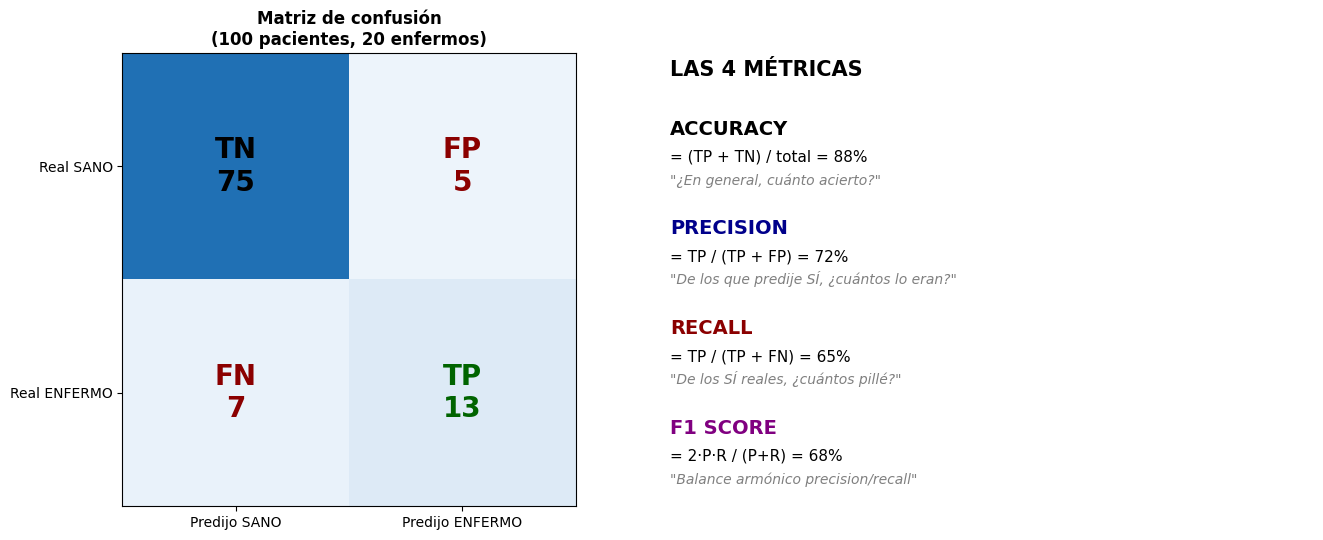

In [28]:
# Generamos la cheatsheet con matplotlib para que quede dentro del notebook
# plt.subplots(1, 2, ...) crea una figura con 2 subgráficos en una fila.
#   figsize=(ancho, alto) en pulgadas
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ============== IZQUIERDA: matriz de confusión grande ==============

# np.array([[fila0],[fila1]]) crea una matriz 2×2
# TN=75, FP=5, FN=7, TP=13 (100 pacientes, 20 enfermos); 
# TN: "verdaderos negativos", FP: "falsos positivos", FN: "falsos negativos", TP: "verdaderos positivos"
cm_ej = np.array([[75, 5], [7, 13]])

# Etiquetas de texto para cada casilla (TP/FP/FN/TN + número)
# Atención: \n dentro del string genera salto de línea en la celda
labels = [['TN\n75', 'FP\n5'], ['FN\n7', 'TP\n13']]
colors = [['black', 'darkred'], ['darkred', 'darkgreen']]

ax = axes[0] # panel izquierdo para la matriz de confusión
# imshow pinta una matriz como imagen coloreada
#   cmap='Blues' → escala de azules
#   vmin/vmax    → rango fijo para que el color sea consistente
ax.imshow(cm_ej, cmap='Blues', vmin=0, vmax=100)

# Pintamos las etiquetas en cada celda con ax.text(x, y, texto, ...)
for i in range(2):
    for j in range(2):
        ax.text(j, i, labels[i][j], ha='center', va='center',
                fontsize=20, fontweight='bold', color=colors[i][j])

# set_xticks define DÓNDE poner las marcas; set_xticklabels qué texto mostrar
ax.set_xticks([0,1]); ax.set_xticklabels(['Predijo SANO', 'Predijo ENFERMO'])
ax.set_yticks([0,1]); ax.set_yticklabels(['Real SANO', 'Real ENFERMO'])
ax.set_title('Matriz de confusión\n(100 pacientes, 20 enfermos)', fontweight='bold')

# ============== DERECHA: las 4 fórmulas ==============

ax2 = axes[1]
ax2.axis('off')   # quita ejes/marcas en el panel derecho (solo texto)

# ax2.text(x, y, texto, ...) → (x,y) en coordenadas de 0 a 1 dentro del panel
ax2.text(0.02, 0.95, 'LAS 4 MÉTRICAS', fontsize=15, fontweight='bold')

ax2.text(0.02, 0.82, 'ACCURACY', fontsize=14, fontweight='bold')
ax2.text(0.02, 0.76, '= (TP + TN) / total = 88%', fontsize=11)
ax2.text(0.02, 0.71, '"¿En general, cuánto acierto?"', fontsize=10, style='italic', color='gray')

ax2.text(0.02, 0.60, 'PRECISION', fontsize=14, fontweight='bold', color='darkblue')
ax2.text(0.02, 0.54, '= TP / (TP + FP) = 72%', fontsize=11)
ax2.text(0.02, 0.49, '"De los que predije SÍ, ¿cuántos lo eran?"', fontsize=10, style='italic', color='gray')

ax2.text(0.02, 0.38, 'RECALL', fontsize=14, fontweight='bold', color='darkred')
ax2.text(0.02, 0.32, '= TP / (TP + FN) = 65%', fontsize=11)
ax2.text(0.02, 0.27, '"De los SÍ reales, ¿cuántos pillé?"', fontsize=10, style='italic', color='gray')

ax2.text(0.02, 0.16, 'F1 SCORE', fontsize=14, fontweight='bold', color='purple')
ax2.text(0.02, 0.10, '= 2·P·R / (P+R) = 68%', fontsize=11)
ax2.text(0.02, 0.05, '"Balance armónico precision/recall"', fontsize=10, style='italic', color='gray')

plt.tight_layout()    # ajusta márgenes para que no se solapen los textos
plt.show()            # muestra la figura

In [29]:
#import
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# carga de datos
_data = load_breast_cancer()
x_comp= _data.data # características (features) del dataset de cáncer de mama
y_comp= 1 - _data.target  # invertimos las clases para que la clase positiva sea la minoritaria (cáncer)

#split estratificado para mantener la proporción de clases en train/test
Xc_tr_c, Xc_te_c, yc_tr_c, yc_te_c = train_test_split(
    x_comp, y_comp, test_size=0.3, stratify=y_comp, random_state=42)


_scaler = StandardScaler()  # estandarizador para normalizar las características
Xc_tr_cs = _scaler.fit_transform(Xc_tr_c)  # ajusta el scaler al train y transforma
Xc_te_cs = _scaler.transform(Xc_te_c)      # transforma el test con el mismo scaler

print(f"Train: {Xc_tr_cs.shape}, Test: {Xc_te_cs.shape}")
 

Train: (398, 30), Test: (171, 30)


In [30]:
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=5000),
    'Random Forest': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42)
}

resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(Xc_tr_cs, yc_tr_c)  # entrenamos el modelo con el train estandarizado
    y_pred = modelo.predict(Xc_te_cs)  # predecimos con el test estandarizado
    
    # Calculamos las métricas básicas
    acc = accuracy_score(yc_te_c, y_pred)
    prec = precision_score(yc_te_c, y_pred)
    rec = recall_score(yc_te_c, y_pred)
    f1 = f1_score(yc_te_c, y_pred)
    
    resultados[nombre] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    }
    print(f"{nombre}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")




 

Logistic Regression: Accuracy=0.9708, Precision=0.9836, Recall=0.9375, F1=0.9600
Random Forest: Accuracy=0.9708, Precision=1.0000, Recall=0.9219, F1=0.9593
KNN: Accuracy=0.9649, Precision=1.0000, Recall=0.9062, F1=0.9508
Decision Tree: Accuracy=0.9064, Precision=0.9615, Recall=0.7812, F1=0.8621


In [31]:
print("Descargamos Spambase de OpenML...") # mensaje para indicar que empieza la descarga, ya que puede tardar unos segundos

# fetch_openml descarga el dataset 'spambase' desde OpenML.org
#parser="Auto" es el parser recomendado para evitar problemas de codificación con algunos datasets
spam = fetch_openml('spambase', version=1, as_frame=True, parser="auto")
print("listo!")
 

Descargamos Spambase de OpenML...


HTTPError: HTTP Error 504: Gateway Time-out

In [ ]:
# X_spam = spam.data
# y_spam = (spam.target.astype(int) == 1).astype(int)  # convertimos a 0/1 (0=ham, 1=spam)

# X_spam.head(3)

In [ ]:
import pandas as pd

# URL directa al dataset Spambase (es un repositorio muy fiable)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data"

# Cargamos el dataset. 
# Nota: Este dataset no tiene nombres de columnas en la primera fila, así que ponemos header=None
spam = pd.read_csv(url, header=None)

# Para que no sea un lío de números, le echamos un vistazo rápido
print("¡Dataset cargado con éxito!")
print(f"Forma del dataset: {spam.shape}") # Nos dirá cuántas filas y columnas tiene
spam.head() # Muestra las primeras 5 filas

¡Dataset cargado con éxito!
Forma del dataset: (4601, 58)


,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [ ]:
# 1. Separamos las características (X). 
# Queremos todas las filas y todas las columnas EXCEPTO la última.
 # iloc[:, :-1] significa "todas las filas, todas las columnas excepto la última", lo que nos da solo las características 
 # (sin la etiqueta de spam/ham)
X_spam = spam.iloc[:, :-1] 

# 2. Separamos el objetivo (y).
# Queremos todas las filas de la ÚLTIMA columna solamente.
# iloc[:, -1] significa "todas las filas, solo la última columna", que es nuestra etiqueta de spam (1) o ham (0)
y_spam = spam.iloc[:, -1] 

# 3. Ahora verificamos
print("Primeras filas de X (Características):")
print(X_spam.head(3))

print("\nPrimeras etiquetas de y (¿Es Spam?):")
print(y_spam.head(3))

Primeras filas de X (Características):
     0     1     2    3     4     5     6     7     8     9   ...   47    48  \
0  0.00  0.64  0.64  0.0  0.32  0.00  0.00  0.00  0.00  0.00  ...  0.0  0.00   
1  0.21  0.28  0.50  0.0  0.14  0.28  0.21  0.07  0.00  0.94  ...  0.0  0.00   
2  0.06  0.00  0.71  0.0  1.23  0.19  0.19  0.12  0.64  0.25  ...  0.0  0.01   

      49   50     51     52     53     54   55    56  
0  0.000  0.0  0.778  0.000  0.000  3.756   61   278  
1  0.132  0.0  0.372  0.180  0.048  5.114  101  1028  
2  0.143  0.0  0.276  0.184  0.010  9.821  485  2259  

[3 rows x 57 columns]

Primeras etiquetas de y (¿Es Spam?):
0    1
1    1
2    1
Name: 57, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# Dividimos el dataset en cuatro trozos:
# Xs_tr (X Train): Las preguntas para estudiar
# Xs_te (X Test): Las preguntas del examen final
# ys_tr (y Train): Las respuestas del estudio
# ys_te (y Test): Las respuestas correctas del examen (para comparar)
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
    X_spam,              # Tus características (columnas 0-56)
    y_spam,              # Tu objetivo (columna 57, ¿es spam?)
    test_size=0.3,       # El 30% de los datos se reservan para el examen (test)
    
    # ¡OJO A ESTE! Stratify asegura que si hay un 40% de spam en el total,
    # haya un 40% de spam en el grupo de entrenamiento y un 40% en el de test.
    # Evita que el azar deje un grupo sin ejemplos de una de las clases.
    stratify=y_spam,     
    
    # Esto es la "semilla". Sirve para que, si ejecutas el código mañana, 
    # la mezcla sea exactamente la misma y los resultados sean reproducibles.
    random_state=42      
)

print(f"Train: {len(Xs_tr)} emails") # Debería salir ~3220 correos
print(f"Test: {len(Xs_te)} emails")  # Debería salir ~1381 correos

Train: 3220 emails
Test: 1381 emails


In [ ]:
# Ahora entrenamos un modelo de regresión logística con el set de entrenamiento
# max_iter=2000 es un hiperparámetro. Los modelos de clasificación no encuentran la solución de golpe, sino que van haciendo 
# intentos (iteraciones) para reducir el error. Es para asegurarnos de que converge, ya que a veces con este dataset 
# puede necesitar más iteraciones
model_spam = LogisticRegression(max_iter=2000) 

# entrenamos el modelo con el set de entrenamiento, es decir, le damos las preguntas (Xs_tr) y las respuestas correctas 
# (ys_tr) para que aprenda la relación entre ellas
model_spam.fit(Xs_tr, ys_tr)

print("Modelo entrenado con Spambase!")


Modelo entrenado con Spambase!


In [ ]:
# Con el modelo ya entrenado, ahora queremos ver qué tal se defiende en el examen (test).
# predict(Xs_te) hace que el modelo use lo que ha aprendido para predecir las etiquetas de los correos del test.
ys_pred = model_spam.predict(Xs_te)
print("Predicciones realizadas con el modelo de spam!")

#Comparamos predicción vs realidad en las 10 primeras muestras del test
#.values para convertir la serie a array y evitar que se muestre el índice en el DataFrame resultante
pd.DataFrame({
    "Predicción": ys_pred[:10], # mostramos solo las primeras 10 predicciones para no saturar la tabla
    "Valor Real": ys_te.values[:10] # mostramos solo las primeras 10 etiquetas reales para comparar
})

Predicciones realizadas con el modelo de spam!


,Predicción,Valor Real
0,0,0
1,0,0
2,1,1
3,1,1
4,1,1
5,0,0
6,0,0
7,1,1
8,0,1
9,0,0


In [ ]:
# Ahora queremos un resumen de las métricas de clasificación para nuestro modelo. 
# classification_report nos da un resumen completo de precision, recall, f1-score y support para cada clase.
# (sklearn.metrics.classification_report). Lo que hace es comparar, fila por fila, tu "Examen Real" (ys_te) 
# contra las "Respuestas del Alumno" (ys_pred).
print(classification_report(ys_te, ys_pred, target_names=['Ham', 'Spam']))

              precision    recall  f1-score   support

         Ham       0.93      0.95      0.94       837
        Spam       0.92      0.90      0.91       544

    accuracy                           0.93      1381
   macro avg       0.93      0.92      0.92      1381
weighted avg       0.93      0.93      0.93      1381



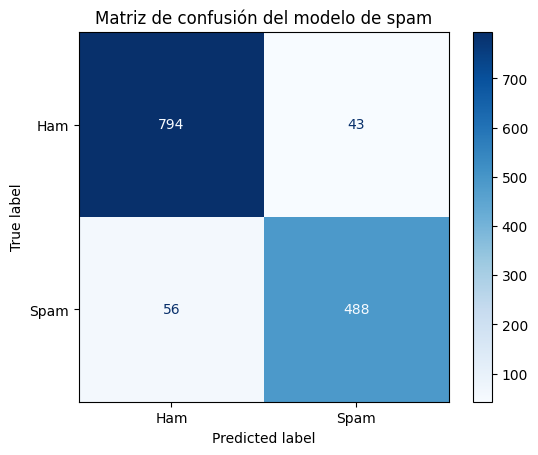

In [ ]:
ConfusionMatrixDisplay.from_predictions(ys_te, ys_pred, display_labels=['Ham', 'Spam'], cmap='Blues')
plt.title("Matriz de confusión del modelo de spam")
plt.show()

- Verdaderos Positivos (TP): Predijiste Spam y ERA Spam. (¡Bien!)

- Verdaderos Negativos (TN): Predijiste Ham y ERA Ham. (¡Bien!)

- Falsos Positivos (FP): Predijiste Spam pero ERA Ham. (¡Error! Un correo importante se fue a la basura).

- Falsos Negativos (FN): Predijiste Ham pero ERA Spam. (¡Error! Te entró basura en la bandeja de entrada).

- Precision (Precisión): ¿De todos los que marqué como Spam, cuántos lo eran de verdad? Es la métrica de la fiabilidad. Si es baja, estás enviando correos buenos a la carpeta de Spam.

- Recall (Sensibilidad/Exhaustividad): De todos los Spam reales que existían, ¿cuántos fui capaz de cazar? Si es bajo, se te están escapando muchos anuncios de "Criptomonedas" a la bandeja principal.

- F1-Score: Es una media entre las dos anteriores. Si ambas son altas, el F1 será alto. Es muy útil cuando quieres un solo número para comparar modelos.

- Support: Simplemente te dice cuántos correos de cada tipo había en tu examen (837 Ham y 544 Spam).

- La fila Ham te dice qué tan bueno es el modelo detectando correos legítimos.

- La fila Spam te dice qué tan bueno es detectando basura.

Esto es vital porque un modelo puede ser un genio detectando Ham pero un desastre detectando Spam (o viceversa).

### Los Promedios (Macro vs. Weighted)
Aquí es donde muchos se lían. Imaginemos que tenemos 1000 correos: 990 son Ham y solo 10 son Spam.

- Accuracy (Exactitud): Es el porcentaje de aciertos totales. Si el modelo dice "Ninguno es spam", tendría un 99% de Accuracy (¡parece perfecto!), pero no ha detectado ni un solo spam. Por eso el Accuracy es peligroso.

- Macro Avg: Calcula la métrica para Ham, la métrica para Spam y hace la media aritmética simple. Trata a todas las clases por igual, sin importar cuántas muestras haya de cada una. Es ideal si te importa tanto el Spam como el Ham por igual.

Weighted Avg: Hace la media, pero dándole más peso a la clase que tiene más ejemplos (en tu caso, el Ham tiene más peso porque hay 837 frente a 544). Es un reflejo más fiel de la "realidad" de tu buzón.

Relación con la Matriz de Confusión
Cuando ejecutas ConfusionMatrixDisplay.from_predictions, visualizas los errores.

Si ves números altos en la diagonal (arriba-izquierda y abajo-derecha), tu Accuracy será alto.

Si ves muchos números en el cuadro de "Predicho: Spam | Real: Ham", tu Precision para la clase Spam bajará.

Regla de oro: Cuando el coste de "omitir" un caso positivo (abandonos, enfermedades, incendios) es mucho más alto que el coste de una "falsa alarma", siempre priorizamos el Recall.

In [21]:
ys_proba = model_spam.predict_proba(Xs_te)[:, 1]  # probabilidades de la clase positiva (spam)
print("Probabilidades de spam para las primeras 10 muestras del test:")


print(f"{'Umbral':>5} | {'Precision':>9} | {'Recall':>6} | {'FP':>4} | {'FN':>4}")

for threshold in [0.3, 0.5, 0.7, 0.9]: # umbrales o límites a evaluar
  pred = (ys_proba >= threshold).astype(int)  # convertimos a 0/1 según el umbral
  p = precision_score(ys_te, pred) # calculamos precisión con las predicciones ajustadas al umbral
  r = recall_score(ys_te, pred) # calculamos recall con las predicciones ajustadas al umbral

  fp = ((pred == 1) & (ys_te == 0)).sum()  # falsos positivos
  fn = ((pred == 0) & (ys_te == 1)).sum()
  # Imprimimos la fila de la tabla:
  #   :>9.3f → 9 caracteres ancho, 3 decimales, formato float
  #   :>4    → 4 caracteres ancho, entero
  print(f"{threshold:>5} | {p:>9.3f} | {r:>6.3f} | {fp:>4} | {fn:>4}") 
  

 

Probabilidades de spam para las primeras 10 muestras del test:
Umbral | Precision | Recall |   FP |   FN
  0.3 |     0.850 |  0.949 |   91 |   28
  0.5 |     0.919 |  0.897 |   43 |   56
  0.7 |     0.944 |  0.807 |   26 |  105
  0.9 |     0.976 |  0.599 |    8 |  218


La verdad oculta: El modelo no predice 0 o 1Aunque cuando hacemos .predict() el modelo nos da un 0 o un 1, la realidad es que por dentro la Regresión Logística calcula una probabilidad (un número entre 0 y 1).
- model_spam.predict_proba(Xs_te)[:, 1] extrae esa probabilidad.
- Por ejemplo, para un correo, el modelo puede decir: "Estoy un 85% seguro de que es Spam".
#### ¿Qué es el Threshold (Umbral)?Por defecto, Scikit-Learn usa un umbral de: 0.5.
- Si probabilidad >= 0.5 -> Clase 1 (Spam).
- Si probabilidad < 0.5  -> Clase 0 (Ham).
El threshold es la "barra" que subimos o bajamos para ser más o menos estrictos.

¿Para qué sirve cambiarlo? (El juego de la balanza)
Imagina que eres un guardia de seguridad. Cambiar el umbral es como decidir qué tan sospechosa tiene que ser una persona para que le pidas el DNI.

Escenario A: Umbral Alto (0.9) - "El Juez Conservador"
Solo marcas como Spam lo que es extremadamente evidente.

- Consecuencia: Tu Precision sube muchísimo (no cometes errores, no bloqueas correos buenos).

- Problema: Tu Recall baja (se te escapan muchos spams que solo tenían un 70% u 80% de probabilidad). Tendrás muchos Falsos Negativos (FN).

Escenario B: Umbral Bajo (0.3) - "El Guardia Paranoico"
A la mínima sospecha, marcas como Spam.

- Consecuencia: Tu Recall sube (cazas casi toda la basura).

- Problema: Tu Precision baja porque empezarás a marcar correos buenos como spam. Tendrás muchos Falsos Positivos (FP).

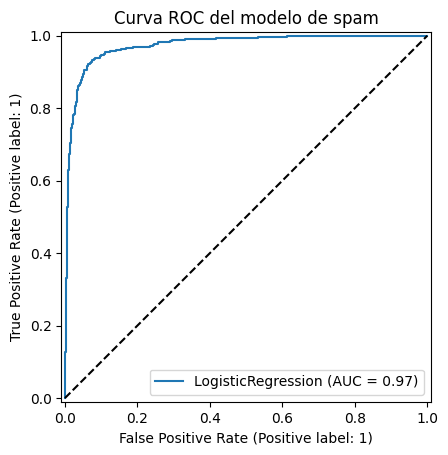

In [32]:
from sklearn.metrics import RocCurveDisplay

# Dibujamos la curva usando las probabilidades
RocCurveDisplay.from_estimator(model_spam, Xs_te, ys_te)
plt.plot([0, 1], [0, 1], "k--") # Línea diagonal de "suerte al azar"
plt.title("Curva ROC del modelo de spam")
plt.show()

¿Cómo se lee este gráfico?
- El eje Y (True Positive Rate): Es el Recall. Cuanto más alto, más basura (o inundaciones) detectamos.

- El eje X (False Positive Rate): Es la probabilidad de dar una falsa alarma.

- La curva ideal: Es la que se pega lo más posible a la esquina superior izquierda. Significa que puedes tener un Recall altísimo (1.0) sin casi tener falsas alarmas (0.0).

El valor AUC (Area Under the Curve)
El AUC es un solo número que resume qué tan bueno es el modelo en todos los umbrales posibles.

- AUC = 0.5: El modelo es igual de útil que lanzar una moneda al aire. (Es la línea diagonal punteada).

- AUC = 0.8 - 0.9: Es un modelo muy bueno.

- AUC = 1.0: El modelo es perfecto (sospechosamente perfecto, probablemente haya algún error en los datos).

In [33]:
diabetes = fetch_openml(name='diabetes', version=1, as_frame=True, parser='auto')
X_d = diabetes.data
y_d = (diabetes.target == 'tested_positive').astype(int)   # 1 = diabetes, 0 = sano

print(f"Total: {len(y_d)} pacientes | Diabetes: {y_d.sum()} ({y_d.mean():.1%})")
X_d.head(3)

HTTPError: HTTP Error 504: Gateway Time-out

In [ ]:
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(
    X_d, y_d, test_size=0.3,
    stratify=y_d, random_state=42
)

print(f"Train: {len(Xd_tr)} pacientes")
print(f"Test: {len(Xd_te)} pacientes")

Train: 537 pacientes
Test: 231 pacientes


In [ ]:
model_diabetes = LogisticRegression(max_iter=2000)


model_diabetes.fit(Xd_tr, yd_tr)


print("Modelo entrenado con Diabetes!")

Modelo entrenado con Diabetes!


In [ ]:
yd_pred = model_diabetes.predict(Xd_te)
print("Predicciones realizadas con el modelo de diabetes!")

#Comparamos predicción vs realidad en las 10 primeras muestras del test
#.values para convertir la serie a array y evitar que se muestre el índice en el DataFrame resultante
pd.DataFrame({
    "Predicción": yd_pred[:10],
    "Valor Real": yd_te.values[:10]
})

Predicciones realizadas con el modelo de diabetes!


,Predicción,Valor Real
0,0,1
1,0,1
2,1,1
3,1,1
4,0,1
5,0,0
6,1,0
7,0,0
8,0,0
9,0,0


In [ ]:
print(classification_report(yd_te, yd_pred, target_names=['No Diabetes', 'Diabetes']))

              precision    recall  f1-score   support

 No Diabetes       0.77      0.86      0.81       150
    Diabetes       0.67      0.52      0.58        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.70       231
weighted avg       0.73      0.74      0.73       231



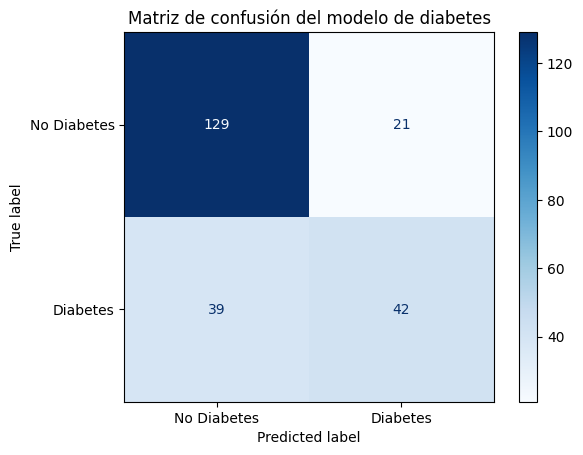

In [24]:
ConfusionMatrixDisplay.from_predictions(yd_te, yd_pred, display_labels=['No Diabetes', 'Diabetes'], cmap='Blues')
plt.title("Matriz de confusión del modelo de diabetes")
plt.show()

In [ ]:
modelos_diabetes = {
    'Logistic Regression': LogisticRegression(max_iter=5000),
    'Random Forest': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42)
}

resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(Xd_tr, yd_tr)  # entrenamos el modelo con el train estandarizado
    y_pred = modelo.predict(Xd_te)  # predecimos con el test estandarizado
    
    # Calculamos las métricas básicas
    acc = accuracy_score(yd_te, y_pred)
    prec = precision_score(yd_te, y_pred)
    rec = recall_score(yd_te, y_pred)
    f1 = f1_score(yd_te, y_pred)
    
    resultados[nombre] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    }
    print(f"{nombre}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")

Logistic Regression: Accuracy=0.7403, Precision=0.6667, Recall=0.5185, F1=0.5833
Random Forest: Accuracy=0.7619, Precision=0.7097, Recall=0.5432, F1=0.6154
KNN: Accuracy=0.7186, Precision=0.6212, Recall=0.5062, F1=0.5578
Decision Tree: Accuracy=0.7662, Precision=0.8000, Recall=0.4444, F1=0.5714


In [ ]:
# Cargamos el dataset de cáncer de mama incluido en sklearn
cancer = load_breast_cancer()
print("Dataset de cáncer de mama cargado con éxito!")

Dataset de cáncer de mama cargado con éxito!


In [ ]:
cancer.head(5)

In [ ]:
Xc = cancer.data

yc = 1 - cancer.target

print(f"Total muestras: {len(yc)}")
print(f"Cáncer (maligno, 1): {yc.sum()} ({yc.mean():.1%})")
print(f"Sano (benigno, 0): {len(yc) - yc.sum()} ({1 - yc.mean():.1%})")

Total muestras: 569
Cáncer (maligno, 1): 212 (37.3%)
Sano (benigno, 0): 357 (62.7%)


In [ ]:
pd.DataFrame(Xc, columns=cancer.feature_names).iloc[:3, :5]

,mean radius,mean texture,mean perimeter,mean area,mean smoothness
0,17.99,10.38,122.8,1001.0,0.11840
1,20.57,17.77,132.9,1326.0,0.08474
2,19.69,21.25,130.0,1203.0,0.10960


In [ ]:
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.3, stratify=yc, random_state=42
)

model_cancer = LogisticRegression(max_iter=5000).fit(Xc_tr, yc_tr)
print("Modelo de cáncer entrenado con éxito!")

Modelo de cáncer entrenado con éxito!


In [ ]:
# .predict() → clase predicha (0 ó 1) con threshold por defecto 0.5
yc_pred = model_cancer.predict(Xc_te)

# .predict_proba()[:, 1] → probabilidad de la clase 1 (cáncer)
# La guardamos porque la usaremos para mover el threshold luego.
yc_proba = model_cancer.predict_proba(Xc_te)[:, 1]

print(f"Primeras 10 predicciones: {yc_pred[:10]}")
print(f"Sus probabilidades:        {yc_proba[:10].round(3)}")

Primeras 10 predicciones: [0 0 0 0 0 0 1 0 0 0]
Sus probabilidades:        [0.289 0.007 0.    0.002 0.01  0.    0.999 0.039 0.395 0.   ]


In [34]:
print(classification_report(yc_te, yc_pred, target_names=["beningno", "cáncer"]))

              precision    recall  f1-score   support

    beningno       0.92      0.99      0.95       107
      cáncer       0.98      0.86      0.92        64

    accuracy                           0.94       171
   macro avg       0.95      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171



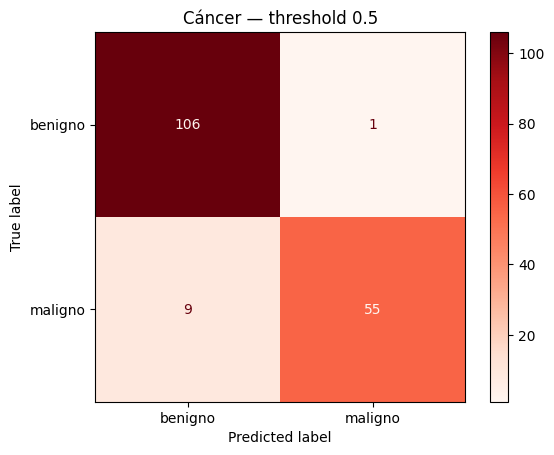


⚠️ Con threshold 0.5 hemos mandado a casa a 9 enfermo(s) de 64


In [35]:
# Visualizamos la matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    yc_te, yc_pred, display_labels=["benigno", "maligno"], cmap="Reds"
)
plt.title("Cáncer — threshold 0.5"); plt.show()

# Contamos los FN (falsos negativos) = pacientes con cáncer enviados a casa
# Máscara: predijo 0 (sano) AND era 1 (cáncer)
fn_default = ((yc_pred == 0) & (yc_te_c == 1)).sum()
print(f"\n⚠️ Con threshold 0.5 hemos mandado a casa a {fn_default} enfermo(s) de {yc_te_c.sum()}")

In [36]:
yc_proba = model_cancer.predict_proba(Xc_te)[:, 1]  # probabilidades de la clase positiva (spam)
print("Probabilidades de cancer para las primeras 10 muestras del test:")


print(f"{'Umbral':>5} | {'Precision':>9} | {'Recall':>6} | {'FP':>4} | {'FN':>4}")

for threshold in [0.3, 0.5, 0.7, 0.9]:
  yc_pred = (yc_proba >= threshold).astype(int)  # convertimos a 0/1 según el umbral
  p = precision_score(yc_te, yc_pred)
  r = recall_score(yc_te, yc_pred)

  fp = ((yc_pred == 1) & (yc_te == 0)).sum()  # falsos positivos
  fn = ((yc_pred == 0) & (yc_te == 1)).sum()
  # Imprimimos la fila de la tabla:
  #   :>9.3f → 9 caracteres ancho, 3 decimales, formato float
  #   :>4    → 4 caracteres ancho, entero
  print(f"{threshold:>5} | {p:>9.3f} | {r:>6.3f} | {fp:>4} | {fn:>4}")

Probabilidades de cancer para las primeras 10 muestras del test:
Umbral | Precision | Recall |   FP |   FN
  0.3 |     0.967 |  0.922 |    2 |    5
  0.5 |     0.982 |  0.859 |    1 |    9
  0.7 |     0.981 |  0.828 |    1 |   11
  0.9 |     1.000 |  0.766 |    0 |   15


In [37]:
# np.arange(start, stop, step) genera valores espaciados regularmente
#   0.99, 0.98, 0.97, ..., 0.01  (step negativo = de mayor a menor)
mejor_thr = None
for thr in np.arange(0.99, 0.0, -0.01):
    # Generamos predicciones aplicando este threshold sobre las probas
    pred = (yc_proba >= thr).astype(int)

    # Cuando el recall llega a 1.0, no hay FN → cogemos ESTE threshold (el más alto que cumple)
    if recall_score(yc_te_c, pred) == 1.0:
        mejor_thr = thr
        break    # salimos del bucle en cuanto encontramos el primero

# Calculamos métricas con el threshold óptimo encontrado
pred_opt = (yc_proba >= mejor_thr).astype(int)
fp = ((pred_opt == 1) & (yc_te_c == 0)).sum()
fn = ((pred_opt == 0) & (yc_te_c == 1)).sum()

print(f"🎯 Threshold más alto con recall=1.0: {mejor_thr:.2f}")
print(f"   Precision: {precision_score(yc_te_c, pred_opt):.2%}")
print(f"   FP (biopsias innecesarias): {fp}")
print(f"   FN (cánceres no detectados): {fn}  ← debe ser 0")
print(f"\n💬 Antes mandábamos a casa a {fn_default} enferm@; ahora ninguno, a cambio de {fp} biopsias extra.")

🎯 Threshold más alto con recall=1.0: 0.04
   Precision: 82.05%
   FP (biopsias innecesarias): 14
   FN (cánceres no detectados): 0  ← debe ser 0

💬 Antes mandábamos a casa a 9 enferm@; ahora ninguno, a cambio de 14 biopsias extra.


In [38]:
modelos_cancer = {
    'Logistic Regression': LogisticRegression(max_iter=5000),
    'Random Forest': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42)
}

resultados = {}

for nombre, modelo in modelos_cancer.items():
    modelo.fit(Xc_tr, yc_tr)  # entrenamos el modelo con el train estandarizado
    y_pred = modelo.predict(Xc_te)  # predecimos con el test estandarizado
    
    # Calculamos las métricas básicas
    acc = accuracy_score(yc_te, y_pred)
    prec = precision_score(yc_te, y_pred)
    rec = recall_score(yc_te, y_pred)
    f1 = f1_score(yc_te, y_pred)
    
    resultados[nombre] = {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    }
    print(f"{nombre}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")

Logistic Regression: Accuracy=0.9415, Precision=0.9821, Recall=0.8594, F1=0.9167
Random Forest: Accuracy=0.9708, Precision=1.0000, Recall=0.9219, F1=0.9593
KNN: Accuracy=0.9298, Precision=0.9815, Recall=0.8281, F1=0.8983
Decision Tree: Accuracy=0.9064, Precision=0.9615, Recall=0.7812, F1=0.8621


In [43]:
print(classification_report(yc_te, y_pred, target_names=["beningno", "cáncer"]))

              precision    recall  f1-score   support

    beningno       0.88      0.98      0.93       107
      cáncer       0.96      0.78      0.86        64

    accuracy                           0.91       171
   macro avg       0.92      0.88      0.90       171
weighted avg       0.91      0.91      0.90       171



| Modelo | Cómo funciona | Tipo de datos idóneo | Cuándo brilla | Cuándo NO usar |
|---|---|---|---|---|
| **LogisticRegression** | Frontera lineal entre clases | Numérico, features independientes | Dataset tabular, relación lineal o casi, **interpretabilidad** | Relaciones muy no lineales |
| **KNN** | "Te clasifico como tus K vecinos más parecidos" | Numérico, **misma escala** (¡estandarizar!) | Datasets pequeños, fronteras irregulares | Muchas features (curse of dimensionality), datasets grandes |
| **DecisionTree** | Encadena preguntas tipo "¿edad > 30?" | Numérico **y/o** categórico mezclado | Reglas explicables, no requiere escalar | Overfittea fácilmente si no se poda |
| **RandomForest** | Promedia 100+ árboles de decisión | Tabular en general, mixto numérico/categórico | "Modelo por defecto" para tabular. Robusto sin tunear. | Cuando necesitas **explicar** la decisión (es caja negra) |
| **SVM** | Busca el "margen máximo" entre clases | Numérico estandarizado, **muchas features** | Texto (bag-of-words), datasets medianos con alta dimensión | Datasets grandes (>50k filas → lento) |
| **GradientBoosting / XGBoost** | Suma árboles, cada uno corrige al anterior | Tabular, mixto | Suele ganar competiciones Kaggle. Top en tabular. | Cuando no te puedes permitir tunear hiperparámetros |
| **NaïveBayes** | Probabilidades suponiendo features independientes | Texto (frecuencia de palabras) | Spam, clasificación de texto, rápido y simple | Cuando las features están muy correlacionadas |